### **Project work part 1 - IND320**
### Malk Adwan

##### **Imports and load data**

In [191]:
import pandas as pd
import matplotlib.pyplot as plt

In [221]:
#reading the file
df_file = pd.read_csv(r"C:\Users\malki\OneDrive - Norwegian University of Life Sciences\UNI5\IND320-1\Project\data\reservoirs.csv")

##### **Describing the dataset and preprocessing**

In [222]:
#general information about the data
#size of the dataset
# the first 5 rows of the dataset
#information about the columns of the dataset

print(df_file.shape)
print(df_file.head())
print(df_file.info())

(14877, 11)
      dato_Id omrType  omrnr  iso_aar  iso_uke  fyllingsgrad  kapasitet_TWh  \
0  1995-09-03      EL      4     1995       35      0.944721      21.079208   
1  2020-11-15      EL      1     2020       46      0.974361       6.003264   
2  2011-08-28      EL      4     2011       34      0.786499      21.079208   
3  1998-07-05      EL      3     1998       27      0.793969       8.920932   
4  2011-03-27      EL      4     2011       12      0.300820      21.079208   

   fylling_TWh neste_Publiseringsdato  fyllingsgrad_forrige_uke  \
0    19.913979    0001-01-01T00:00:00                  0.936888   
1     5.849344    2020-11-25T13:00:00                  0.997406   
2    16.578772    0001-01-01T00:00:00                  0.787193   
3     7.082947    0001-01-01T00:00:00                  0.733812   
4     6.341054    0001-01-01T00:00:00                  0.311122   

   endring_fyllingsgrad  
0              0.007833  
1             -0.023046  
2             -0.000694  
3     

In [223]:
#describing the dataset in a more statistical sense 
#along with number of observations for each column
print(df_file.describe())
print(df_file.isna().sum())

              omrnr       iso_aar       iso_uke  fyllingsgrad  kapasitet_TWh  \
count  14877.000000  14877.000000  14877.000000  14877.000000   14877.000000   
mean       2.333333   2010.346038     26.405929      0.618852      29.145860   
std        1.490762      9.146696     15.017910      0.214850      22.739070   
min        0.000000   1995.000000      1.000000      0.055160       6.003264   
25%        1.000000   2002.000000     13.000000      0.456234      17.390587   
50%        2.000000   2010.000000     26.000000      0.648049      23.237715   
75%        3.000000   2018.000000     39.000000      0.802135      34.043590   
max        5.000000   2026.000000     53.000000      1.020072      87.437580   

        fylling_TWh  fyllingsgrad_forrige_uke  endring_fyllingsgrad  
count  14877.000000              14877.000000          14877.000000  
mean      18.139713                  0.618890             -0.000038  
std       15.966211                  0.214843              0.031385  

The dataset looks complete in the sense of no missing values in any of the columns. Stay tuned to find out if this truly is the case. The first registration was made in 1996 (min-value for iso-aar) while the latest registration was made in 2026.

Some of the headers explain themselves, others are not that easy to interpret. 

In [ ]:
df = df_file #renaming

#renaming the columns of the dataset
df = df.rename(columns={'dato_Id': 'Date', "omrType": "Area_type", "omrnr": "Area_number",
                        "iso_aar": "ISO_year","iso_uke": "ISO_week", 
                        "fyllingsgrad": "Filling_level", "kapasitet_TWh": "Capacity_TWh", 
                        "fylling_TWh": "Filling_TWh",
                        "neste_Publiseringsdato": "Next_publishdate",
                        "fyllingsgrad_forrige_uke": "Filling_level_prev_week", 
                        "endring_fyllingsgrad": "Change_filling_level"})

#sorting the dataframe by date so the datapoints become sequential
df = df.sort_values("Date") 

In [225]:
#checking if the changes worked
df.head()

,Date,Area_type,Area_number,ISO_year,ISO_week,Filling_level,Capacity_TWh,Filling_TWh,Next_publishdate,Filling_level_prev_week,Change_filling_level
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657


We see that "Next_publishdate" for some measurements are 0001-01-01T00:00:00, which doesnt give any intiuitive sense, but it could be that before that date, the system wasnt digitalised. This date is then the minimum date. 

We can observe that the column "Date" is in the format off YYYY-MM-DD, but the type is an object, and the same is for "Next_Publishdate". 

In [226]:
# converting the date columns to datetime format
for col in ["Date", "Next_publishdate"]:
    df[col] = pd.to_datetime(df[col], format="ISO8601", errors="coerce")

print(df[["Date", "Next_publishdate"]].dtypes)

Date                datetime64[ns]
Next_publishdate    datetime64[ns]
dtype: object


In [227]:
#checking if the changes were made
df.head()

,Date,Area_type,Area_number,ISO_year,ISO_week,Filling_level,Capacity_TWh,Filling_TWh,Next_publishdate,Filling_level_prev_week,Change_filling_level
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,NaT,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,NaT,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,NaT,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,NaT,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,NaT,0.777604,-0.146657


NaT = Not a Time. Happens when there are missing dates within a dataframe. 0001-01-01T00:00:00 is not a date and the value therefore becomes NaT. So even though isna().sum() gave us that there is no missing values, by actually inspecting the dataset we see that there is indeed missing values. 

##### **Plotting each column**

In [228]:
print(df["Area_type"].unique()) #checking unique values in the Area_type column
print(df.groupby("Area_type")["Area_number"].unique())

['EL' 'VASS' 'NO']
Area_type
EL      [5, 4, 3, 1, 2]
NO                  [0]
VASS          [2, 1, 3]
Name: Area_number, dtype: object


This columns seems to hold information about how the data is categorized in areas, wether it is
- NO: The whole country of Norway
- EL: one of the five electricity price areas
    - EL1
    - EL2
    - EL3
    - EL4
    - EL5
- VASS: river basin area (Vassdragsområde)
    - VASS1
    - VASS2
    - VASS3

Text(0.5, 1.0, 'Observations by Area')

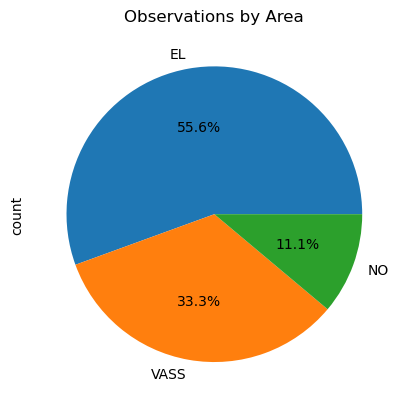

In [229]:
# how many observations are made for each area type
df["Area_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Observations by Area")

Text(0.5, 1.0, 'Observations for each area number within the area type')

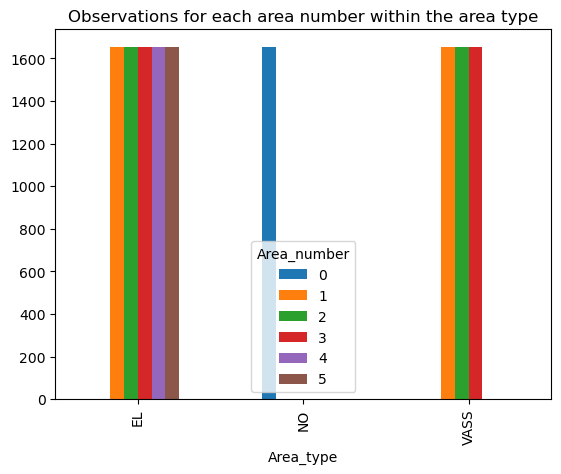

In [230]:
#different area numbers for each area type
df.groupby(["Area_type", "Area_number"]).size().unstack(fill_value=0).plot(kind="bar")
plt.title("Observations for each area number within the area type")

NO has no area number as it covers the whole country, so the default area number is zero. However, each area number is represented in the same amount, this can also seen in the pie chart.

Text(0.5, 1.0, 'Observations by ISO year')

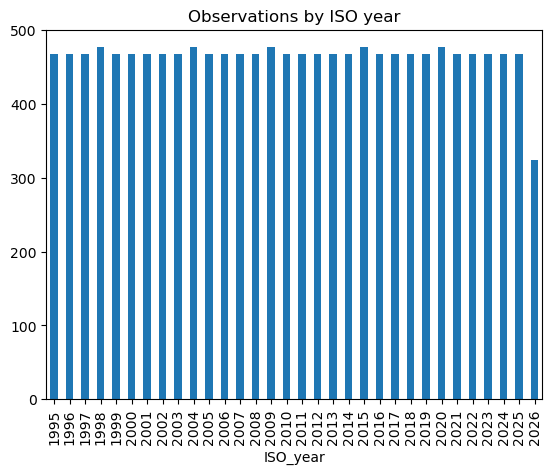

In [231]:
#how many observations there are for each ISO year
#ISO years are essentially observations throughout the years, grouped by year
df["ISO_year"].value_counts().sort_index().plot(kind="bar")
plt.title("Observations by ISO year")

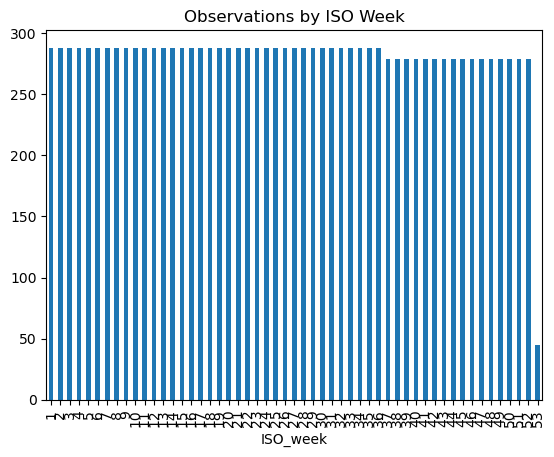

In [232]:
#how many observations there are for each ISO week
#ISO weeks are essentially obervations throughout the years, grouped by week number
df["ISO_week"].value_counts().sort_index().plot(kind="bar")
plt.title("Observations by ISO Week")
plt.show()

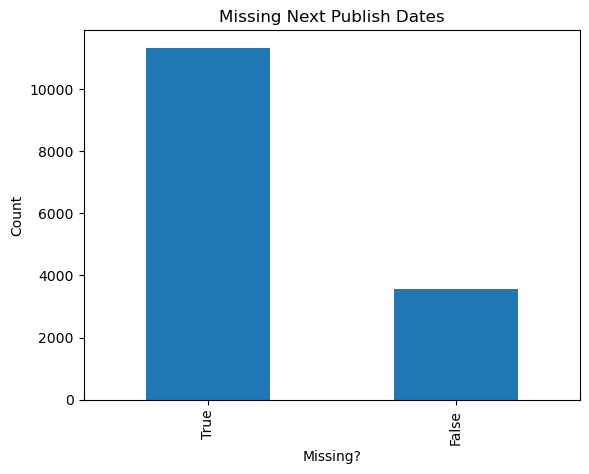

In [233]:
#how many of the Next_publishdate is NaT
df["Next_publishdate"].isna().value_counts().plot(kind="bar")
plt.title("Missing Next Publish Dates")
plt.xlabel("Missing?")
plt.ylabel("Count")
plt.show()

Even though we showed above that there was no missing values, looking further into the data, we now see that the missing values were replaced by a default date, and then when we transfomed the column to have a proper date-format, the missing values became marked as NaT. 



It doesn't make sense to plot the Date-column by itself, so in stead i will group the measurements by month, and then look at when the measurements are taken throughout the seasons of the year. 

Text(0, 0.5, 'Number of Measurements')

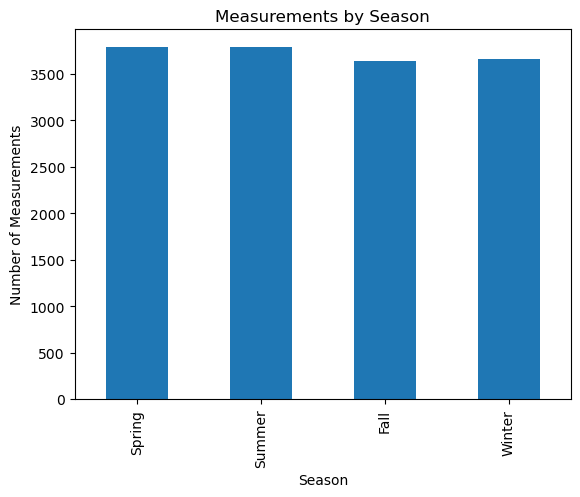

In [234]:
#count the number of measurement for each month of the year
#then assign the months an index from 1-12
monthly_measurements = df["Date"].dt.month.value_counts().sort_index()

#assign the indexed months to their respective season
#sum all the observations for each month within the season
spring_months = monthly_measurements[[3, 4, 5]].sum()
summer_months = monthly_measurements[[6, 7, 8]].sum()
fall_months = monthly_measurements[[9, 10, 11]].sum()
winter_months = monthly_measurements[[12, 1, 2]].sum()

#create a pandas series where each season get its corresponding
#number of measurements
seasonal_measurements =  pd.Series(
    [spring_months, summer_months, fall_months, winter_months],
    index=["Spring", "Summer", "Fall", "Winter"]
)

seasonal_measurements.plot(kind="bar")

plt.title("Measurements by Season")
plt.xlabel("Season")
plt.ylabel("Number of Measurements")

Judging by this, it looks like there are fewer measurements during the colder months in contrary to the summer and spring months. However, the difference doesnt seem signficant. 

Text(0.5, 0, 'Filling Level')

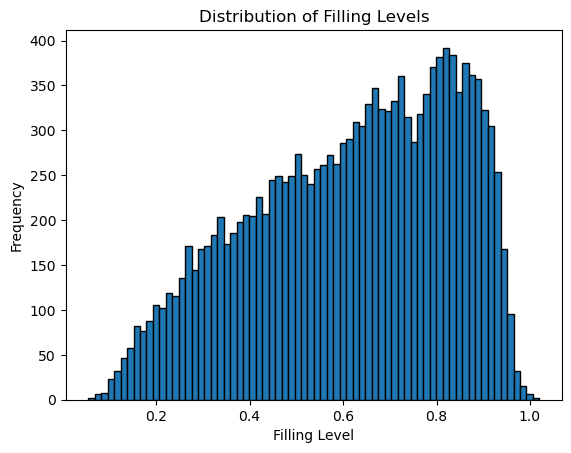

In [235]:
df["Filling_level"].plot(kind="hist", bins=70, edgecolor="black") #tried different bin sizes, 70 seems good
plt.title("Distribution of Filling Levels")
plt.xlabel("Filling Level")


The distribution of the filling level is slightly left-skewed. This means that most reservoirs have relatively high filling levels, but there are some observations with unusually low filling levels. 

Text(0.5, 0, 'Capacity (TWh)')

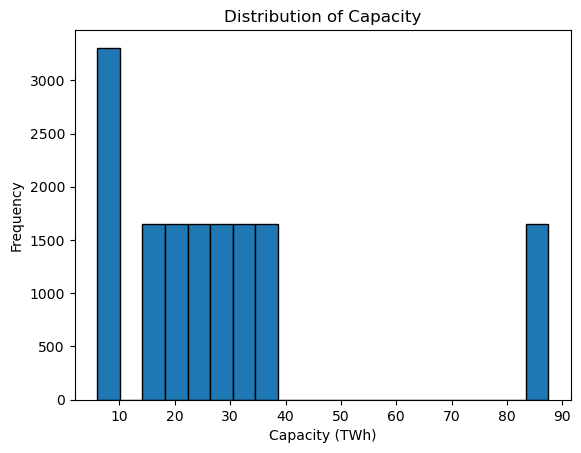

In [236]:
df["Capacity_TWh"].plot(kind="hist", bins=20, edgecolor="black")

plt.title("Distribution of Capacity")
plt.xlabel("Capacity (TWh)")

The distribution of capacity shows that most observations have a capacity of around 10 TWh. The remaining observations are mainly distributed between 15 and 40 TWh, with a few observations having a capacity of approximately 85 TWh.

Text(0.5, 0, 'Filling (TWh)')

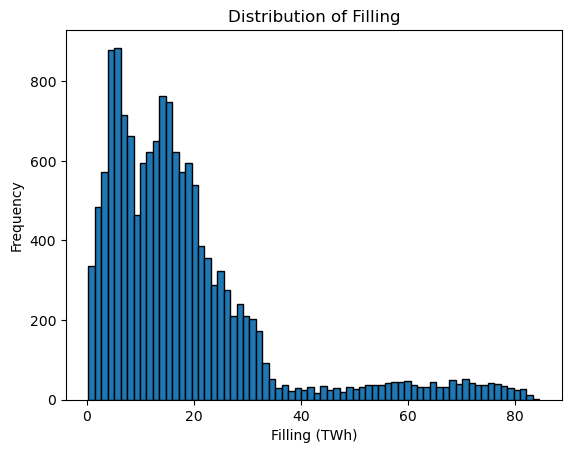

In [237]:
df["Filling_TWh"].plot(kind="hist", bins=70, edgecolor="black")

plt.title("Distribution of Filling")
plt.xlabel("Filling (TWh)")

The distribution of Filling TWh is right-skewed. This means that most observations are concentrated at lower values, while a smaller number of observations have higher values, creating a longer tail toward the right.


Text(0.5, 0, 'Filling level (precentage)')

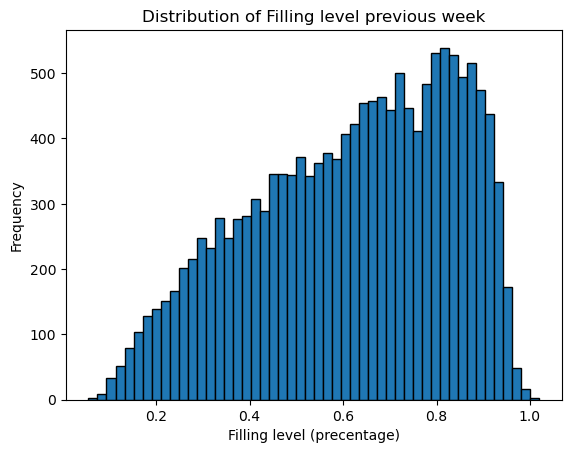

In [238]:
df["Filling_level_prev_week"].plot(kind="hist", bins=50, edgecolor="black")

plt.title("Distribution of Filling level previous week")
plt.xlabel("Filling level (precentage)")

The distributiomn of the filling level for the previous week is slightly left-skewed. Most observations are concentrated toward the higher filling levels, while the observations gradually decrease toward the lower values. However, the skewness is not very pronounced.

Text(0.5, 0, 'Change in filling level (precentage)')

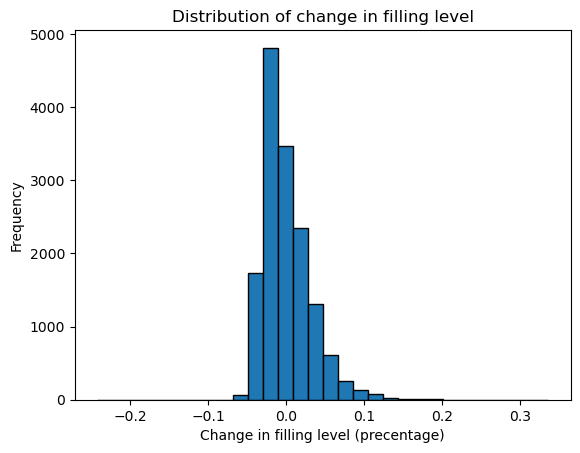

In [239]:
df["Change_filling_level"].plot(kind="hist", bins=30, edgecolor="black")

plt.title("Distribution of change in filling level")
plt.xlabel("Change in filling level (precentage)")

In [240]:
# counting the number of observations for the change in filling level
below_zero = (df["Change_filling_level"] < 0).sum() #the change is negative = less filling than last measured
above_zero = (df["Change_filling_level"] > 0).sum() #the change is positive = more filling than last measured
at_zero = (df["Change_filling_level"] == 0).sum() #the change is zero = no change from last time

print("Below 0:", below_zero)
print("Above 0:", above_zero)
print("Exactly 0:", at_zero)

Below 0: 8704
Above 0: 6173
Exactly 0: 0


Then we have the distribution of the change in filling level. Most observations are below zero, meaning on the left side, giving a distribution with a tail on right-side, making it right-skewed. 

##### **Plotting columns against each other**

Plotting the measurements over time, where the datapoints are grouped by area_type and then looking at area_number for each area_type.

In [241]:
el_area = df[df["Area_type"] == "EL"].copy() #filtering the dataframe to only include rows where Area_type is "EL"
no_area = df[df["Area_type"] == "NO"].copy() #filtering the dataframe to only include rows where Area_type is "NO"
vass_area = df[df["Area_type"] == "VASS"].copy() #filtering the dataframe to only include rows where Area_type is "VASS"

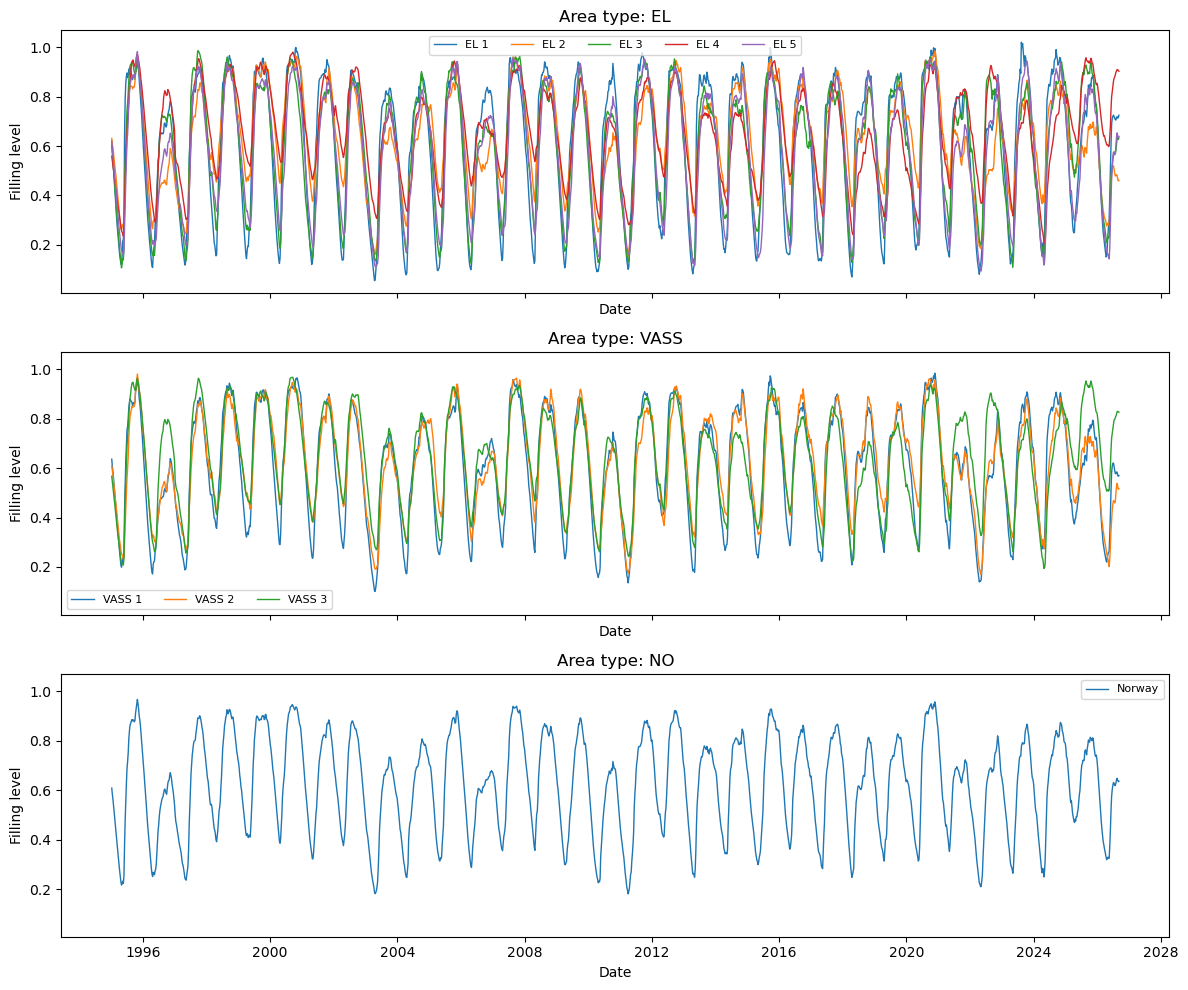

In [242]:
#create 3 plots, one for each Area_type
#the plots are stacked vertically (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(12, 10),
    sharex=True, #use the same Date axis for all plots
    sharey=True #use the same Filling level scale for all plots
)

#loop through each Area_type and its corresponding plot
for ax, area_type in zip(axes, df["Area_type"].unique()):

    #select only observations belonging to the current Area_type
    #and sort them chronologically by Date
    subset = df[df["Area_type"] == area_type].sort_values("Date")

    #group the data by Area_number
    for number, area in subset.groupby("Area_number"):
        #create a label for the legend
        #if the area type is NO, call it "Norway"
        #else use the Area_type and Area_number
        label = "Norway" if area_type == "NO" else f"{area_type} {number}"

        #plot the Filling_level over Date for the current area
        ax.plot(
            area["Date"],
            area["Filling_level"],
            label=label,
            linewidth=1
        )

    #Adding a title showing which Area_type is being displayed
    ax.set_title(f"Area type: {area_type}")
    ax.set_ylabel("Filling level")
    ax.set_xlabel("Date")
    #legend showing which line belongs to which area
    ax.legend(ncol=5, fontsize=8)

plt.tight_layout()
plt.show()

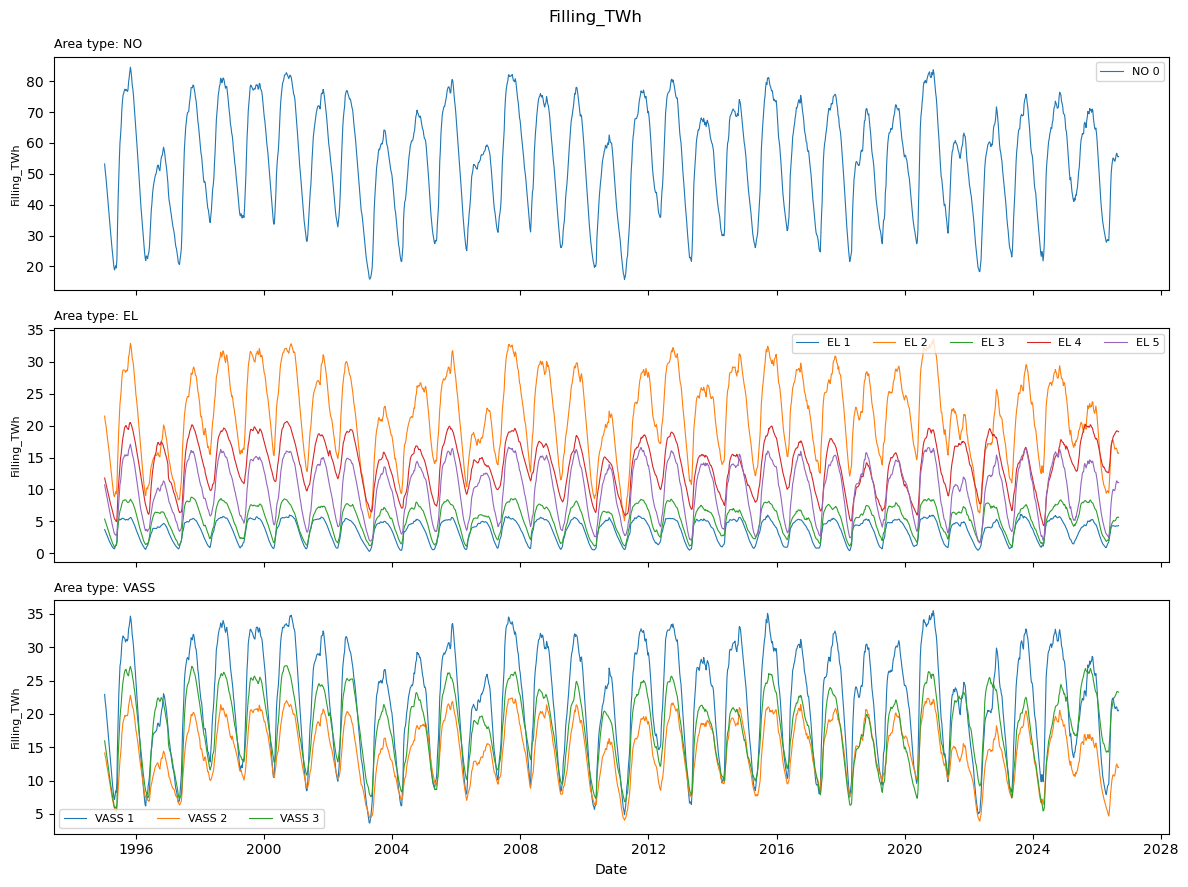

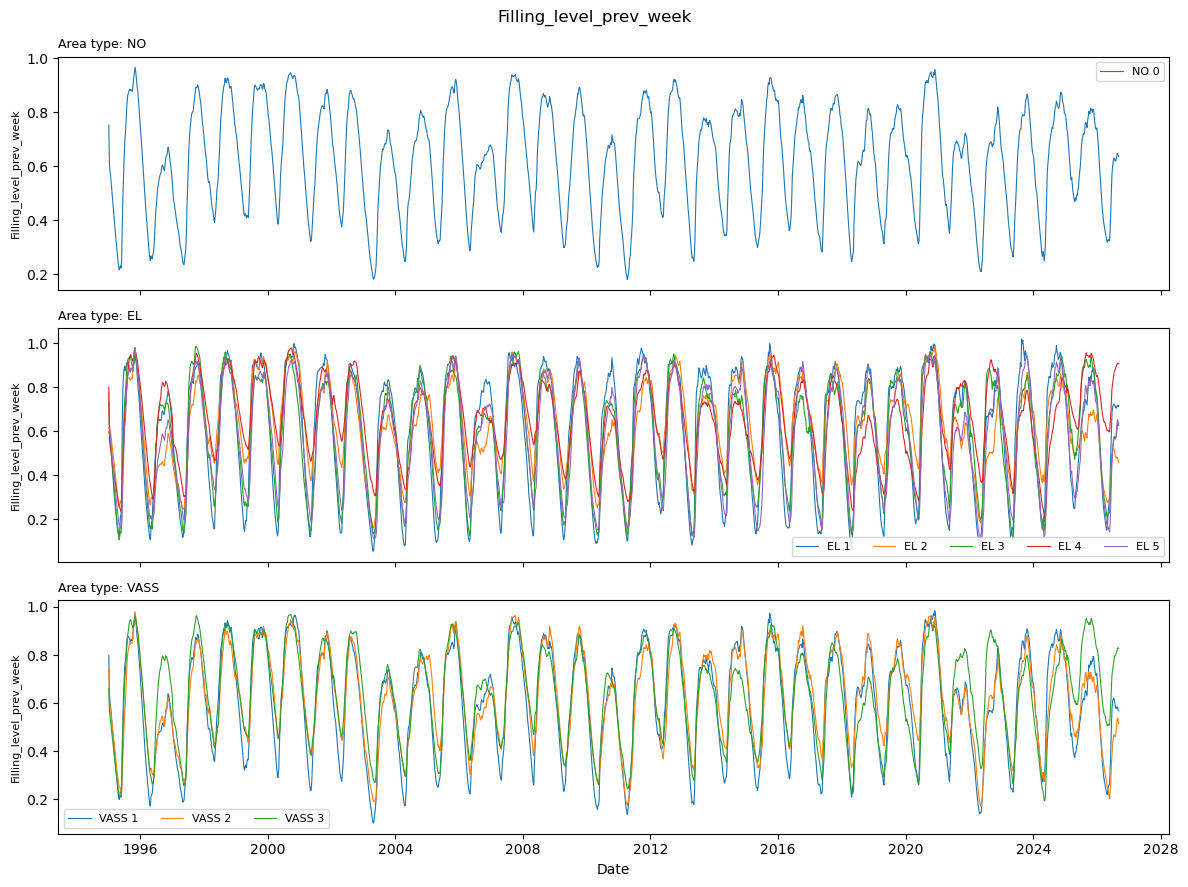

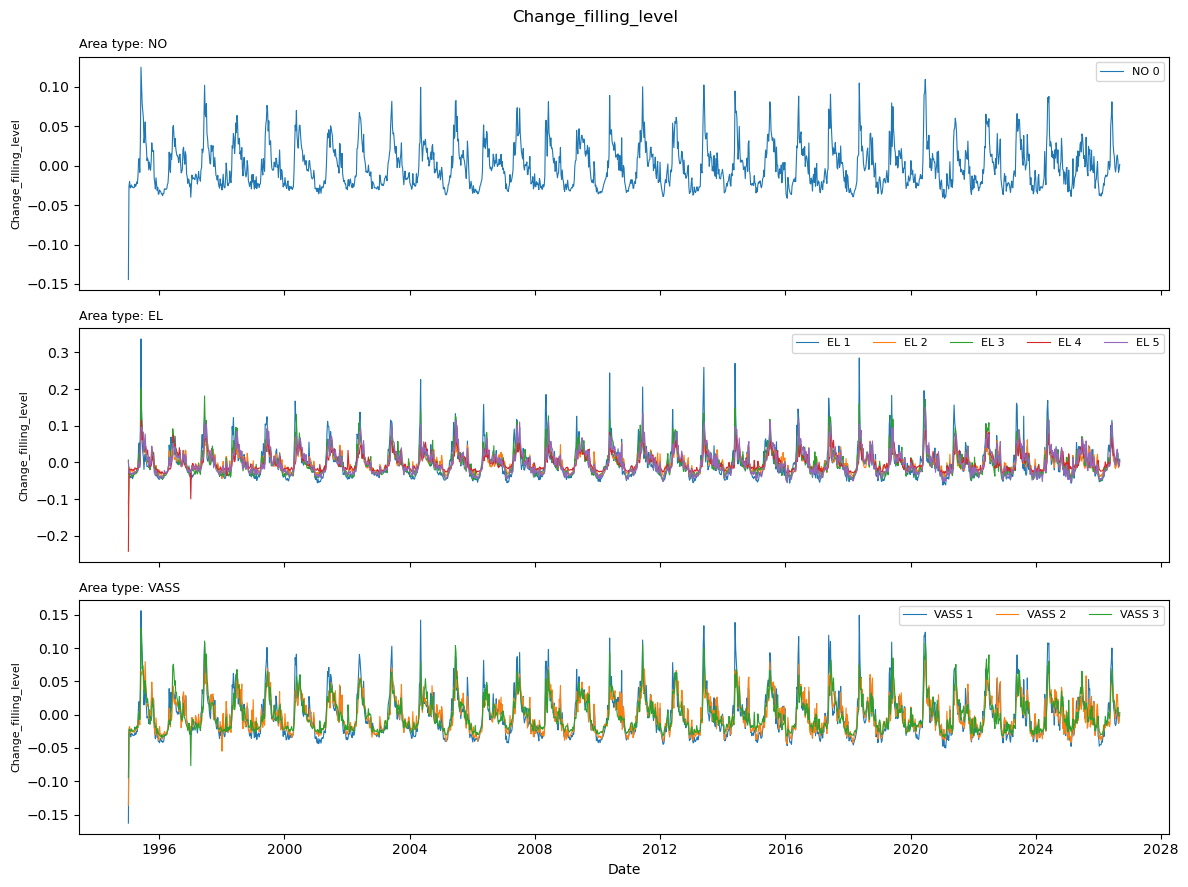

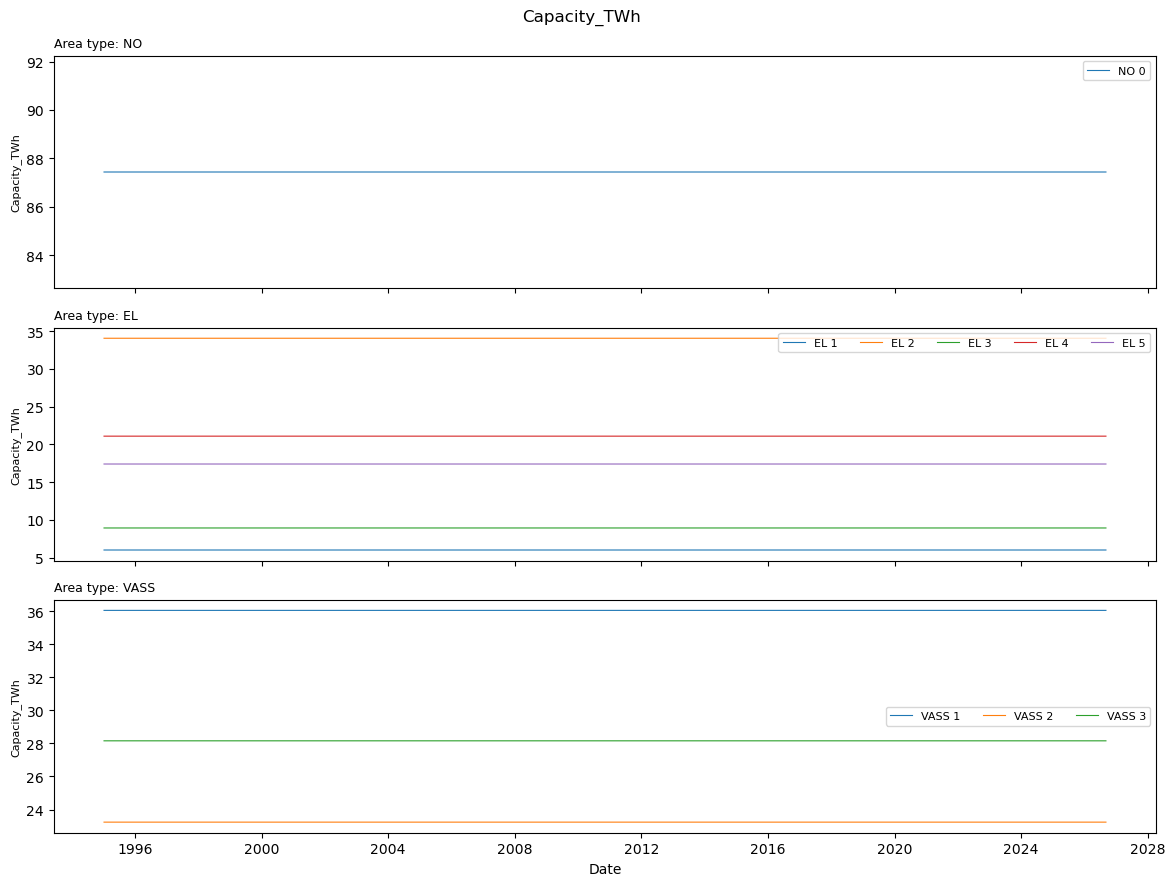

In [243]:
#Lisy of measurement columns that we want to plot
measure_cols = ["Filling_TWh", "Filling_level_prev_week", "Change_filling_level", "Capacity_TWh"]

#Looping through the columns
#for each measure, a figure is created
for col in measure_cols:
    #3 subplots are created for each area type
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    #loop through the area tyoes and their df
    for ax, area_df, area_type in zip(axes, [no_area, el_area, vass_area], ["NO", "EL", "VASS"]):
        #sirting the data by date and then group by Are_number
        for number, g in area_df.sort_values("Date").groupby("Area_number"):
            #plot the selected measurement over time
            #each area number gets its line
            ax.plot(g["Date"], g[col], label=f"{area_type} {number}", linewidth=0.8)

        #which Area_type is being shown
        ax.set_title(f"Area type: {area_type}", loc="left", fontsize=9)
        ax.set_ylabel(col, fontsize=8)
        ax.legend(ncol=5, fontsize=8)

    axes[-1].set_xlabel("Date") #naming the bottom x-axis
    #naming the figure the selected measurement
    fig.suptitle(col)
    plt.tight_layout()
    plt.show()

* Filling (TWh) against date:
  The different colors represent the different area numbers within each area type. VASS-1, EL-2 and NO appear to follow similar trends over time, although they are on different scales. This suggests that the filling levels in these areas tend to increase and decrease in similar periods.

* Filling level in the previous week against date:
  Here, EL-5, VASS-2 and NO appear to follow similar trends over time. The filling level in the previous week also shows relatively consistent patterns between the different areas.

* Change in filling level against date:
  The changes in filling level appear to be relatively small throughout the observed period. There are some larger peaks, particularly around 1996. These peaks could indicate periods with larger changes in reservoir filling levels.

* Capacity (TWh) against date:
  The capacity appears to remain constant for the different area types and area numbers throughout the observed period. This is expected because the capacity represents the maximum storage capacity of the reservoirs rather than the amount of water currently stored. The graphs also show that the same area-number series are present throughout the period.


##### Plotting all the columns for one area_type

Only plotting all the columns for Area_type="NO" so it doesnt look as chaotic. 

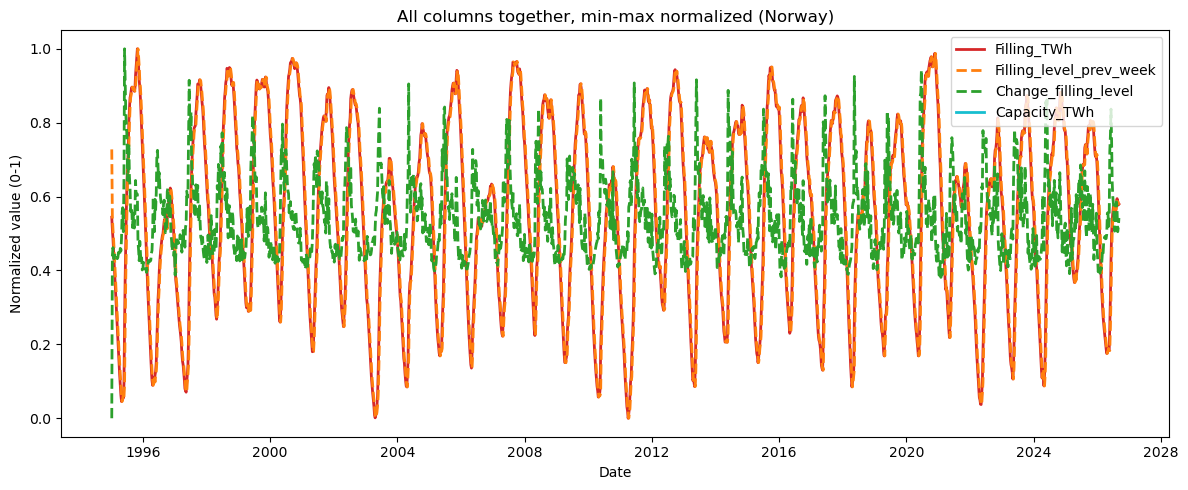

In [244]:
#normalizes all the measurement column to a scale from 0-1
#Makes the columns comparable since they have different scales. 
norm = (no_area[measure_cols ] - no_area[measure_cols ].min()) / (no_area[measure_cols ].max() - no_area[measure_cols].min())

#different line styles to easier differentiate the lines
styles = ["-", "--", "--", "-"]
#different colors for the lines
colors = ["tab:red", "tab:orange", "tab:green", "tab:cyan"]

fig, ax = plt.subplots(figsize=(12, 5))

#looping through each measurement column, linestyle and color
for col, style, color in zip(measure_cols, styles, colors):
    #Plotting the normaøozed measurements over time
    ax.plot(no_area["Date"], norm[col], label=col, linewidth=2.0,
            linestyle=style, color=color)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized value (0-1)")
ax.set_title("All columns together, min-max normalized (Norway)")
ax.legend()
plt.tight_layout()
plt.show()

In [245]:
#calculate the correlation between the normalized measurements
correlations = norm.corr()

print(correlations)

                         Filling_TWh  Filling_level_prev_week  \
Filling_TWh                 1.000000                 0.990009   
Filling_level_prev_week     0.990009                 1.000000   
Change_filling_level        0.069798                -0.071562   
Capacity_TWh                     NaN                      NaN   

                         Change_filling_level  Capacity_TWh  
Filling_TWh                          0.069798           NaN  
Filling_level_prev_week             -0.071562           NaN  
Change_filling_level                 1.000000           NaN  
Capacity_TWh                              NaN           NaN  


In [246]:
#describing the Capacity column for area type NO
#since we get NaN-values
print(no_area["Capacity_TWh"].describe())

count    1.653000e+03
mean     8.743758e+01
std      1.378870e-12
min      8.743758e+01
25%      8.743758e+01
50%      8.743758e+01
75%      8.743758e+01
max      8.743758e+01
Name: Capacity_TWh, dtype: float64


The normalized measurements show that Filling TWh and Filling level in the previous week follow very similar patterns over time. This is also supported by their very high correlation of 0.990. Change in filling level behaves differently and has very little relationship with the other two variables.

Capacity TWh is not visible in the normalized plot because its value is constant in the data for the area we examined. Since the capacity does not change, it cannot be normalized in the same way as the other variables. Therefore, we cannot use this plot to compare the development of capacity with the other measurements.

Overall, the results show that Filling TWh and Filling level in the previous week change in a very similar way, while Change in filling level follows a different pattern.




##### **Log**

I started by reading reservoirs.csv with pandas and exploring its structure. The original column headers were in Norwegian, so I renamed them to English equivalents using a rename dictionary, which made the rest of the analysis easier to write and read.

Working with the Date column surfaced an early issue: many rows contained the placeholder value 0001-01-01T00:00:00, which represents "no date set" but falls outside pandas' default datetime range. I handled this by converting the values to NaT instead of raising an error.

A more significant discovery was that Area_type splits the data into three region types — NO (national total), EL (five electricity price areas), and VASS (three watercourse areas) — and these overlap rather than being independent. Plotting a column without filtering to one area mixed unrelated regions into a single, meaningless line. This meant every plot needed to group or filter by Area_type and Area_number before drawing, which shaped how I approached both the "plot each column" and "plot all columns together" requirements. For the latter, since the columns have very different scales, I applied min-max normalization so they could share one axis meaningfully.

For the Streamlit app, I set up a GitHub repository and connected it to Streamlit Community Cloud, which took some troubleshooting. Streamlit's GitHub App needed explicit permission to see my repository even after making it public, which I resolved by reconfiguring its access under GitHub's installed app settings. I also ran into a version mismatch between the pandas installed in my Jupyter kernel versus the environment streamlit run used locally, which caused format="ISO8601" to silently fail to parse dates, switching to unformatted pd.to_datetime resolved it across environments.

I built the four-page structure with a home page, a data table page using st.column_config.LineChartColumn() to show row-wise sparklines of the first month's data, and a plot page with st.selectbox for column choice and st.select_slider for a month range. I used @st.cache_data on the data-loading function so the CSV is only read once per session rather than on every rerun.

However, I feel that I may have misunderstood parts of the project, as the visualization in my ipynb was not the same as what I understood to be required in the Streamlit app.

##### **AI usage**

I used AI (Anthropic, 2026) assistance throughout for debugging error tracebacks (pandas dtype issues, a matplotlib import error, Streamlit-GitHub permission problems), for reasoning through data-structure questions (what the area types represent and why unfiltered plots looked wrong), and for scaffolding page code, which I then adapted to match my own notebook logic. I also used AI to formulate descriptions and the project log, as well as for language editing (språkvask) to improve wording, grammar, and clarity.

Anthropic. (2026). Claude (Sonnet 5) [Large language model]. https://claude.ai

##### **GitHub and Streamlit app**

GitHub repository: [malkia777/IND320---Project](https://github.com/malkia777/IND320---Project)

Streamlit app: https://share.streamlit.io/user/malkia777"

##### **Panopto link**
https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=bb44b5d6-be35-4a17-9bb2-b4d4015e0fa7
